<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **SpaceX  Falcon 9 First Stage Landing Prediction**


## Assignment: Exploring and Preparing Data


Estimated time needed: **70** minutes


In this assignment, we will predict if the Falcon 9 first stage will land successfully. SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is due to the fact that SpaceX can reuse the first stage.

In this lab, you will perform Exploratory Data Analysis and Feature Engineering.


Falcon 9 first stage will land successfully


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planned. Space X performs a controlled landing in the oceans.


## Objectives

Perform exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`

*   Exploratory Data Analysis
*   Preparing Data  Feature Engineering


### Import Libraries and Define Auxiliary Functions


We will import the following libraries the lab


In [ ]:
import piplite
await piplite.install(['numpy'])
await piplite.install(['pandas'])
await piplite.install(['seaborn'])

In [ ]:
# pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns

## Exploratory Data Analysis


First, let's read the SpaceX dataset into a Pandas dataframe and print its summary


In [19]:
import pandas as pd

# Load the CSV since it's in the same folder as the notebook
df = pd.read_csv('dataset_part_2.csv')

# Display the first 5 rows to verify
df.head()


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


First, let's try to see how the `FlightNumber` (indicating the continuous launch attempts.) and `Payload` variables would affect the launch outcome.

We can plot out the <code>FlightNumber</code> vs. <code>PayloadMass</code>and overlay the outcome of the launch. We see that as the flight number increases, the first stage is more likely to land successfully. The payload mass also appears to be a factor; even with more massive payloads, the first stage often returns successfully.


In [ ]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

Next, let's drill down to each site visualize its detailed launch records.


### TASK 1: Visualize the relationship between Flight Number and Launch Site


Use the function <code>catplot</code> to plot <code>FlightNumber</code> vs <code>LaunchSite</code>, set the  parameter <code>x</code>  parameter to <code>FlightNumber</code>,set the  <code>y</code> to <code>Launch Site</code> and set the parameter <code>hue</code> to <code>'class'</code>


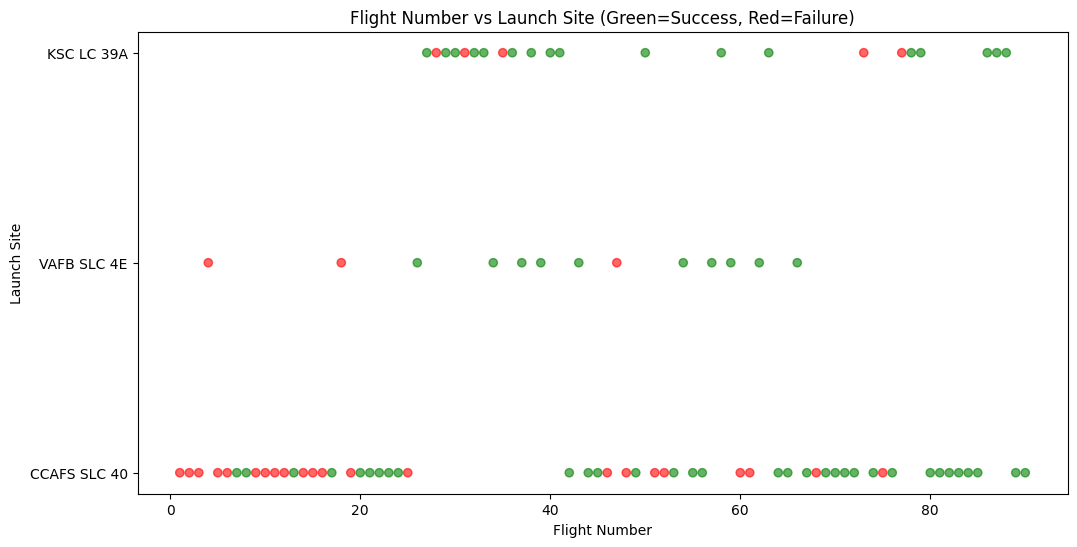

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('dataset_part_2.csv')

# Scatter plot of FlightNumber vs LaunchSite colored by Class
colors = df['Class'].map({1:'green', 0:'red'})  # Green=Success, Red=Failure

plt.figure(figsize=(12,6))
plt.scatter(df['FlightNumber'], df['LaunchSite'], c=colors, alpha=0.6)
plt.xlabel('Flight Number')
plt.ylabel('Launch Site')
plt.title('Flight Number vs Launch Site (Green=Success, Red=Failure)')
plt.show()


Now try to explain the patterns you found in the Flight Number vs. Launch Site scatter point plots.


In [ ]:
What the plot shows

X-axis (Flight Number): The sequential number of the SpaceX flight.

Y-axis (Launch Site): The location from where the rocket was launched.

Color (Class): Green = Successful launch, Red = Failed launch

2. Patterns you might notice

Some launch sites are more active than others

If a site has more points, it means SpaceX used it for more flights.

Example: CCAFS LC-40 might have a cluster of points, showing it’s heavily used.

Early flights have more failures

Lower Flight Numbers (like 1–10) may have some red points, showing failures were more common in early launches.

This is normal — rockets often improve over time as technology and procedures get refined.

Later flights are almost all successes

Higher Flight Numbers tend to be green, meaning SpaceX learned from past launches and improved reliability.

Some launch sites might have perfect records

Some sites may show only green points, indicating no failed launches at that site.

Distribution over Flight Numbers

You can see clusters of launches by site — some sites are used continuously, others intermittently.


3. Insights / conclusions

Experience matters: Early flights have more failures — reliability improves with time.

Launch site matters less than rocket technology: Most sites eventually achieve mostly successful launches.

High-traffic launch sites: SpaceX concentrates launches at certain sites like CCAFS LC-40 or KSC LC-39A.

### TASK 2: Visualize the relationship between Payload Mass and Launch Site


We also want to observe if there is any relationship between launch sites and their payload mass.


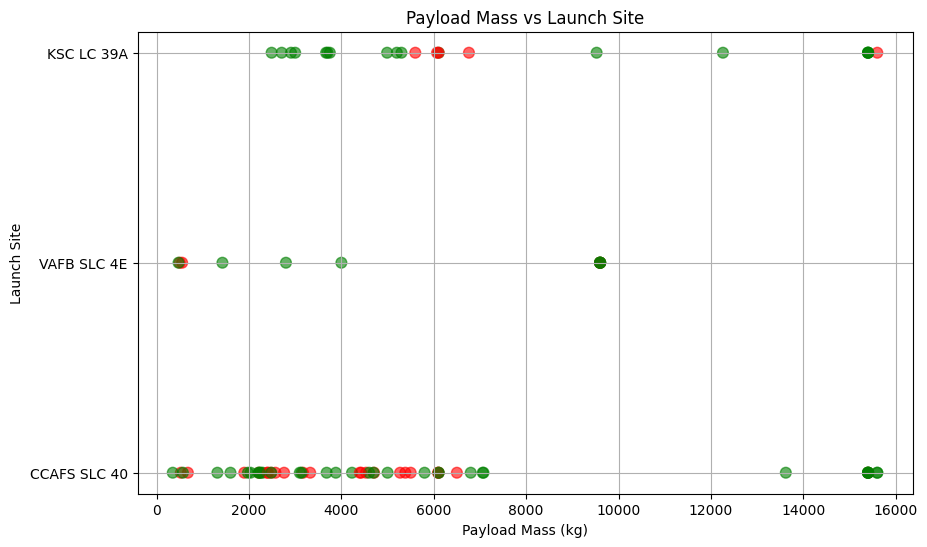

In [25]:
# Plot a scatter point chart with x axis to be Pay Load Mass (kg) and y axis to be the launch site, and hue to be the class value
# Import matplotlib
import matplotlib.pyplot as plt

# Scatter plot of Payload Mass vs Launch Site
plt.figure(figsize=(10,6))
colors = ['green' if c == 1 else 'red' for c in df['Class']]  # Green=Success, Red=Failure

plt.scatter(df['PayloadMass'], df['LaunchSite'], c=colors, alpha=0.6, s=60)

plt.xlabel('Payload Mass (kg)')
plt.ylabel('Launch Site')
plt.title('Payload Mass vs Launch Site')
plt.grid(True)
plt.show()


Now if you observe Payload Mass Vs. Launch Site scatter point chart you will find for the VAFB-SLC  launchsite there are no  rockets  launched for  heavypayload mass(greater than 10000).


### TASK  3: Visualize the relationship between success rate of each orbit type


Next, we want to visually check if there are any relationship between success rate and orbit type.


Let's create a `bar chart` for the sucess rate of each orbit


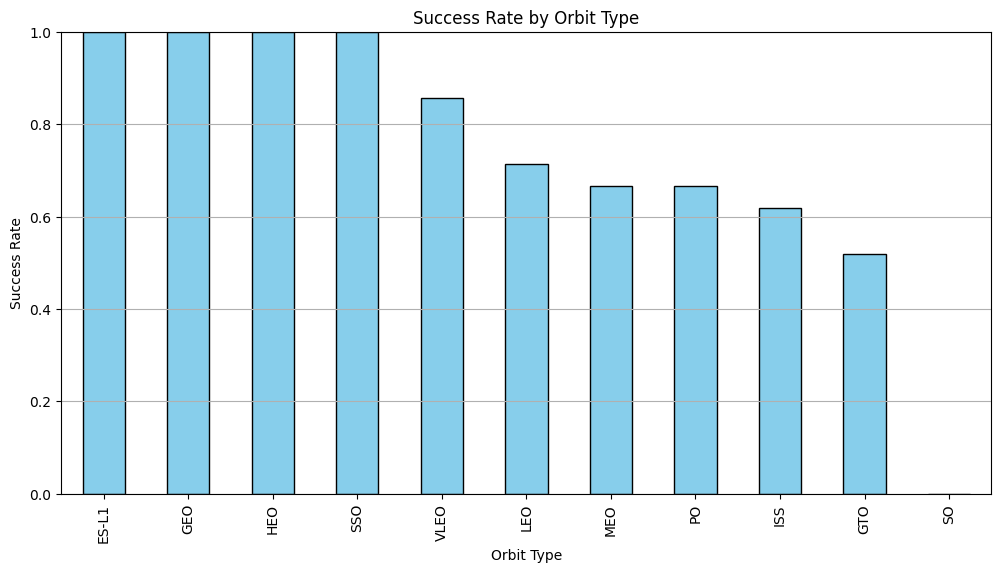

In [26]:
# HINT use groupby method on Orbit column and get the mean of Class column
# Import matplotlib
import matplotlib.pyplot as plt

# Compute success rate per orbit type
orbit_success = df.groupby('Orbit')['Class'].mean().sort_values(ascending=False)

# Plot a bar chart
plt.figure(figsize=(12,6))
orbit_success.plot(kind='bar', color='skyblue', edgecolor='black')

plt.xlabel('Orbit Type')
plt.ylabel('Success Rate')
plt.title('Success Rate by Orbit Type')
plt.ylim(0, 1)  # Since it's a rate
plt.grid(axis='y')
plt.show()


Analyze the plotted bar chart to identify which orbits have the highest success rates.


In [ ]:
Highest Success Rate Orbits:

Orbits with bars reaching 1.0 (or 100% success rate) are the most reliable.

These are the orbits where all launches succeeded in your dataset.

In many SpaceX datasets, these tend to be:

LEO (Low Earth Orbit)

ISS (International Space Station missions)

Some PO or VLEO orbits depending on the dataset

Lower Success Rate Orbits:

Orbits with shorter bars (less than 1.0) indicate some failures occurred.

Often these are GTO (Geostationary Transfer Orbit) or highly ambitious orbits that are technically challenging.

Patterns to notice:

Most of SpaceX’s early failures happen in high-energy or complex orbits.

Simple, frequent orbits (like LEO) have very consistent success.

The chart visually shows risk vs. orbit type — the shorter the bar, the higher the risk of failure.



### TASK  4: Visualize the relationship between FlightNumber and Orbit type


For each orbit, we want to see if there is any relationship between FlightNumber and Orbit type.


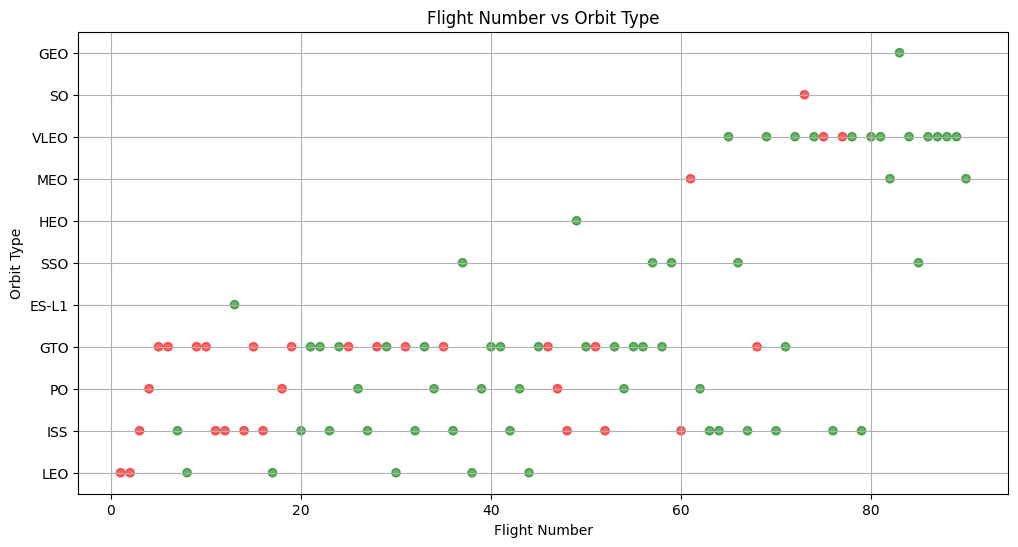

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("dataset_part_2.csv")
df.columns = df.columns.str.strip()  # remove extra spaces

# Map Class to color: 1 = Success (green), 0 = Failure (red)
colors = df['Class'].map({1: 'green', 0: 'red'})

# Plot FlightNumber vs Orbit
plt.figure(figsize=(12,6))
plt.scatter(df['FlightNumber'], df['Orbit'], c=colors, alpha=0.6)

plt.title("Flight Number vs Orbit Type")
plt.xlabel("Flight Number")
plt.ylabel("Orbit Type")
plt.grid(True)
plt.show()


You can observe that in the LEO orbit, success seems to be related to the number of flights. Conversely, in the GTO orbit, there appears to be no relationship between flight number and success.


### TASK  5: Visualize the relationship between Payload Mass and Orbit type


Similarly, we can plot the Payload Mass vs. Orbit scatter point charts to reveal the relationship between Payload Mass and Orbit type


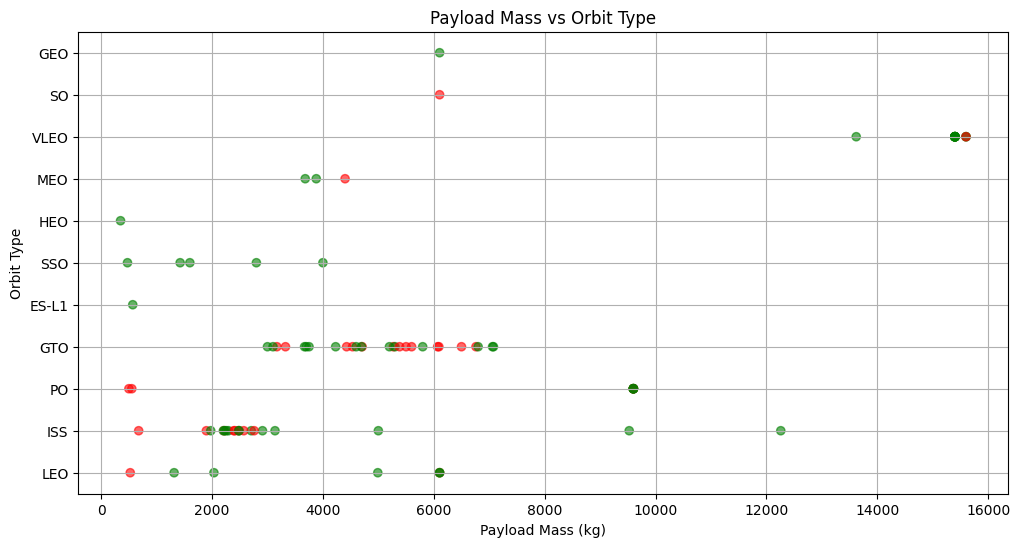

In [29]:
# Plot a scatter point chart with x axis to be Payload Mass and y axis to be the Orbit, and hue to be the class value
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("dataset_part_2.csv")
df.columns = df.columns.str.strip()  # remove any extra spaces

# Map Class to colors: 1 = Success (green), 0 = Failure (red)
colors = df['Class'].map({1: 'green', 0: 'red'})

# Create the scatter plot
plt.figure(figsize=(12,6))
plt.scatter(df['PayloadMass'], df['Orbit'], c=colors, alpha=0.6)

# Add labels and title
plt.xlabel("Payload Mass (kg)")
plt.ylabel("Orbit Type")
plt.title("Payload Mass vs Orbit Type")
plt.grid(True)

# Show plot
plt.show()


With heavy payloads the successful landing or positive landing rate are more for Polar,LEO and ISS.

However, for GTO, it's difficult to distinguish between successful and unsuccessful landings as both outcomes are present.


### TASK  6: Visualize the launch success yearly trend


You can plot a line chart with x axis to be <code>Year</code> and y axis to be average success rate, to get the average launch success trend.


The function will help you get the year from the date:


In [ ]:
# A function to Extract years from the date 
year=[]
def Extract_year():
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
Extract_year()
df['Date'] = year
df.head()
    

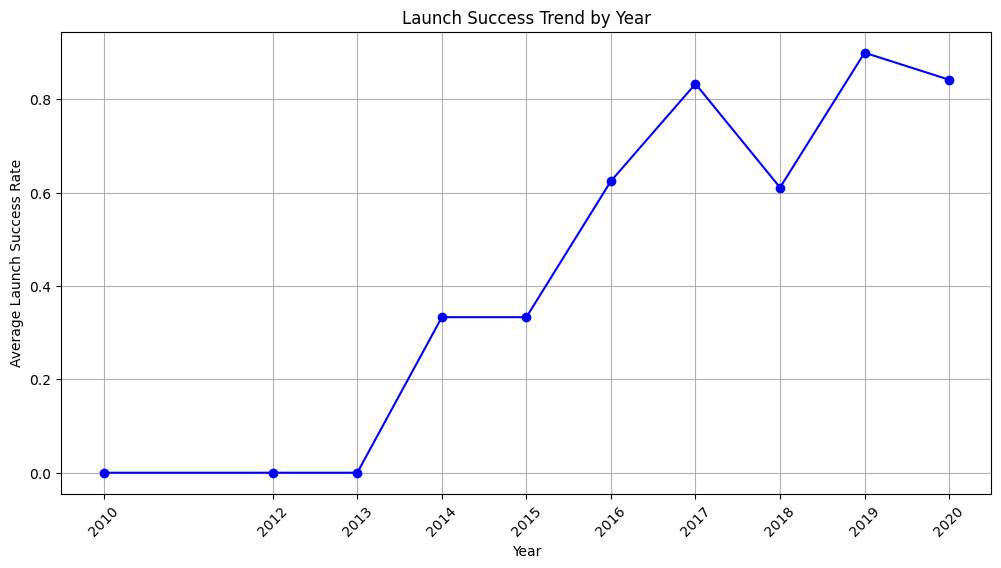

In [30]:
# Plot a line chart with x axis to be the extracted year and y axis to be the success rate
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("dataset_part_2.csv")
df.columns = df.columns.str.strip()  # remove extra spaces

# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Extract year from the date
df['Year'] = df['Date'].dt.year

# Calculate the average success rate per year
success_rate_by_year = df.groupby('Year')['Class'].mean()

# Plot the yearly success trend
plt.figure(figsize=(12,6))
plt.plot(success_rate_by_year.index, success_rate_by_year.values, marker='o', linestyle='-', color='blue')

# Add labels and title
plt.xlabel("Year")
plt.ylabel("Average Launch Success Rate")
plt.title("Launch Success Trend by Year")
plt.grid(True)
plt.xticks(success_rate_by_year.index, rotation=45)

plt.show()


you can observe that the sucess rate since 2013 kept increasing till 2020


## Features Engineering


By now, you should obtain some preliminary insights about how each important variable would affect the success rate, we will select the features that will be used in success prediction in the future module.


In [ ]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

### TASK  7: Create dummy variables to categorical columns


Use the function <code>get_dummies</code> and <code>features</code> dataframe to apply OneHotEncoder to the column <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code>, and <code>Serial</code>. Assign the value to the variable <code>features_one_hot</code>, display the results using the method head. Your result dataframe must include all features including the encoded ones.


In [31]:
# HINT: Use get_dummies() function on the categorical columns
import pandas as pd

# Load the dataset
df = pd.read_csv("dataset_part_2.csv")
df.columns = df.columns.str.strip()  # remove extra spaces

# Select the features we want to encode
categorical_columns = ['Orbit', 'LaunchSite', 'LandingPad', 'Serial']

# Apply One-Hot Encoding
features_one_hot = pd.get_dummies(df, columns=categorical_columns)

# Display first 5 rows
features_one_hot.head()


,FlightNumber,Date,BoosterVersion,PayloadMass,Outcome,Flights,GridFins,Reused,Legs,Block,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,2010-06-04,Falcon 9,6104.959412,None None,1,False,False,False,1.0,...,False,False,False,False,False,False,False,False,False,False
1,2,2012-05-22,Falcon 9,525.000000,None None,1,False,False,False,1.0,...,False,False,False,False,False,False,False,False,False,False
2,3,2013-03-01,Falcon 9,677.000000,None None,1,False,False,False,1.0,...,False,False,False,False,False,False,False,False,False,False
3,4,2013-09-29,Falcon 9,500.000000,False Ocean,1,False,False,False,1.0,...,False,False,False,False,False,False,False,False,False,False
4,5,2013-12-03,Falcon 9,3170.000000,None None,1,False,False,False,1.0,...,False,False,False,False,False,False,False,False,False,False


### TASK  8: Cast all numeric columns to `float64`


Now that our <code>features_one_hot</code> dataframe only contains numbers, cast the entire dataframe to variable type <code>float64</code>


In [33]:

# Select only numeric columns
numeric_cols = features_one_hot.select_dtypes(include=['int64', 'float64']).columns

# Cast only numeric columns to float64
features_one_hot[numeric_cols] = features_one_hot[numeric_cols].astype('float64')

# Verify
features_one_hot.dtypes


FlightNumber      float64
Date               object
BoosterVersion     object
PayloadMass       float64
Outcome            object
                   ...   
Serial_B1056         bool
Serial_B1058         bool
Serial_B1059         bool
Serial_B1060         bool
Serial_B1062         bool
Length: 86, dtype: object

We can now export it to a <b>CSV</b> for the next section,but to make the answers consistent, in the next lab we will provide data in a pre-selected date range.


<code>features_one_hot.to_csv('dataset_part\_3.csv', index=False)</code>


## Authors


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)


<!--## Change Log-->


<!--
| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|
| 2024-07-18        | 1.2     | Anita Verma | Clarified instructions|
-->


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
